In [1]:
import os
import json
import pandas as pd
from glob import glob

# 1. 설정
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data'  # 폴더 경로 확인!
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

print(f"총 {len(json_files)}개의 파일을 검사합니다...")

# 2. 데이터 추출
data_list = []

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # drug_N (우리 프로젝트 코드) 추출
        # (구조에 따라 위치가 다를 수 있음, 보통 images나 annotations, 혹은 최상위에 있음)
        # 일단 안전하게 찾아봅니다.
        drug_n = data.get('drug_N')
        if not drug_n and 'images' in data and len(data['images']) > 0:
             drug_n = data['images'][0].get('drug_N')
             
        # item_seq (품목기준코드) 추출 - 이미지 배열 안에 있음
        item_seq = None
        if 'images' in data and len(data['images']) > 0:
            # images[].item_seq 라고 했으므로 리스트 첫 번째 요소 확인
            item_seq = data['images'][0].get('item_seq')
            
        data_list.append({
            'file_name': os.path.basename(file_path),
            'drug_N': drug_n,
            'item_seq': item_seq
        })

    except Exception as e:
        print(f"Error reading {os.path.basename(file_path)}: {e}")

# DataFrame 변환
df = pd.DataFrame(data_list)

# 3. 검증 결과 분석
print("\n" + "="*50)
print("[item_seq] 품목기준코드 검증 결과")
print("="*50)

# (1) 결측치(Null) 확인
missing_seq = df[df['item_seq'].isnull()]
if len(missing_seq) == 0:
    print("1. 필수값(M) 검증: 모든 데이터에 item_seq가 존재합니다.")
else:
    print(f"1. 필수값(M) 위반: {len(missing_seq)}건의 누락 발생!")
    print(missing_seq.head())

# (2) 타입 확인 (숫자형인지)
# 데이터가 문자열로 들어올 수도 있어서, 숫자로 변환 가능한지 체크
is_digit = df['item_seq'].astype(str).str.replace('.', '', regex=False).str.isnumeric()
invalid_type = df[~is_digit & df['item_seq'].notnull()]

if len(invalid_type) == 0:
    print("2. 타입(Number) 검증: 모두 숫자 형식입니다.")
else:
    print(f"2. 타입 오류: 숫자가 아닌 값이 {len(invalid_type)}건 있습니다.")
    print(invalid_type.head())

# (3) 매칭 정합성 확인 (drug_N <-> item_seq)
# 약 코드 하나에 item_seq가 여러 개 나오면 데이터 꼬인 것임
mapping_check = df.groupby('drug_N')['item_seq'].nunique()
mixed_drugs = mapping_check[mapping_check > 1]

if len(mixed_drugs) == 0:
    print("3. 매칭 검증: drug_N과 item_seq가 1:1로 완벽하게 매칭됩니다.")
else:
    print(f"3. 매칭 오류: 하나의 약 코드에 여러 item_seq가 섞여 있습니다! ({len(mixed_drugs)}건)")
    print(mixed_drugs)

# (4) 샘플 출력
print("\n[데이터 샘플]")
print(df[['drug_N', 'item_seq']].drop_duplicates().head(5))

총 763개의 파일을 검사합니다...

[item_seq] 품목기준코드 검증 결과
1. 필수값(M) 검증: 모든 데이터에 item_seq가 존재합니다.
2. 타입(Number) 검증: 모두 숫자 형식입니다.
3. 매칭 검증: drug_N과 item_seq가 1:1로 완벽하게 매칭됩니다.

[데이터 샘플]
      drug_N   item_seq
0   K-001900  198700706
3   K-016548  200500251
6   K-019607  200607849
9   K-029451  201201587
21  K-033009  201401963


In [2]:
import os
import json
import pandas as pd
from glob import glob

# 1. Configuration
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 

json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)
print(f"Total Files: {len(json_files)}")

# 2. Data Extraction
data_list = []

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # Extract Info
        item_seq = None
        dl_name = None
        
        # images 배열 안에서 정보 추출
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            item_seq = img_info.get('item_seq')
            dl_name = img_info.get('dl_name') # 약 이름 추출
            
        if item_seq and dl_name:
            data_list.append({
                'item_seq': str(item_seq), # 문자로 통일
                'dl_name': dl_name
            })

    except Exception as e:
        pass # 에러는 무시 (이미 앞에서 검증했으므로)

df = pd.DataFrame(data_list)

# 3. Verification Analysis
print("\n" + "="*50)
print("Semantic Integrity Check (Code vs Name)")
print("="*50)

# (1) Name Consistency Check
# 하나의 item_seq에 이름이 몇 개나 있는지 확인
name_counts = df.groupby('item_seq')['dl_name'].nunique()
mixed_names = name_counts[name_counts > 1]

if len(mixed_names) == 0:
    print("1. Name Consistency: OK (One code maps to exactly one name).")
else:
    print(f"Warning: {len(mixed_names)} codes have multiple names!")
    print(mixed_names.head())
    # 문제가 있는 경우 상세 내용 출력
    for code in mixed_names.index[:3]:
        print(f"   Code {code}: {df[df['item_seq'] == code]['dl_name'].unique()}")

# (2) Format Length Check (Standard Korean code is usually 9 digits)
# item_seq가 9자리 숫자인지 확인
df['len'] = df['item_seq'].apply(len)
abnormal_len = df[df['len'] != 9]

if len(abnormal_len) == 0:
    print("2. Format Standard: OK (All codes are 9 digits).")
else:
    print(f"Warning: {len(abnormal_len)} codes have non-standard length!")
    print(abnormal_len['item_seq'].unique())

print("-" * 50)
print("[Sample Data]")
print(df.drop_duplicates().head())

Total Files: 763

Semantic Integrity Check (Code vs Name)
1. Name Consistency: OK (One code maps to exactly one name).
2. Format Standard: OK (All codes are 9 digits).
--------------------------------------------------
[Sample Data]
     item_seq      dl_name  len
0   198700706   보령부스파정 5mg    9
3   200500251  가바토파정 100mg    9
6   200607849    스토가정 10mg    9
9   201201587         레일라정    9
21  201401963         신바로정    9


In [3]:
import os
import json
import pandas as pd
from glob import glob

# 1. Configuration
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 

json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

# 2. Data Extraction
data_list = []

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # 데이터 추출
        item_seq = None
        dl_name = None
        
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            item_seq = img_info.get('item_seq')
            dl_name = img_info.get('dl_name')
            
        if item_seq and dl_name:
            data_list.append({
                'item_seq': str(item_seq), 
                'dl_name': dl_name
            })

    except Exception:
        pass 

df = pd.DataFrame(data_list)

# 3. 중복 제거 (각 약마다 하나씩만 남기기)
unique_pairs = df[['item_seq', 'dl_name']].drop_duplicates().sort_values(by='item_seq')

# 4. 전체 출력 설정 (생략 없이 다 보여주기)
pd.set_option('display.max_rows', None)  # 행 제한 해제
pd.set_option('display.max_colwidth', None) # 글자 잘림 방지
pd.set_option('display.width', 1000) # 가로 넓게

print("\n" + "="*60)
print(f"전체 품목코드-약이름 매핑 리스트 (총 {len(unique_pairs)}종)")
print("="*60)

# 깔끔하게 표 형태로 출력 (인덱스 빼고 출력)
print(unique_pairs.to_string(index=False))

print("\n" + "="*60)
print("검토 팁: 혹시 같은 약인데 이름이 미묘하게 다른지 확인해보세요.")


전체 품목코드-약이름 매핑 리스트 (총 56종)
 item_seq                  dl_name
198700706               보령부스파정 5mg
198801531              뮤테란캡슐 100mg
199101125              일양하이트린정 2mg
199102014       기넥신에프정(은행엽엑스)(수출용)
199102825        무코스타정(레바미피드)(비매품)
199201106                     알드린정
199201807             뉴로메드정(옥시라세탐)
199400486             에어탈정(아세클로페낙)
200202194          리렉스펜정 300mg/PTP
200202889              아빌리파이정 10mg
200300416            다보타민큐정 10mg/병
200301818        써스펜8시간이알서방정 650mg
200308324        에빅사정(메만틴염산염)(비매품)
200410085                리피토정 20mg
200410326               크레스토정 20mg
200500251              가바토파정 100mg
200500254            동아가바펜틴정 800mg
200500497 오마코연질캡슐(오메가-3-산에틸에스테르90)
200511058              리리카캡슐 150mg
200600026  종근당글리아티린연질캡슐(콜린알포세레이트) 
200605445          콜리네이트연질캡슐 400mg
200607734             트루비타정 60mg/병
200607849                스토가정 10mg
200610660                노바스크정 5mg
200611524                     마도파정
200700907               플라빅스정 75mg
200703803            엑스포지정 

In [14]:
import os
import json
import pandas as pd
from glob import glob

# 1. 경로 설정 (아까 성공했던 데이터 경로 유지)
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

# 2. 데이터 추출
data_list = []

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            item_seq = img_info.get('item_seq')
            dl_name = img_info.get('dl_name')
            
            if item_seq and dl_name:
                data_list.append({
                    'item_seq': str(item_seq), 
                    'dl_name': dl_name
                })
    except Exception:
        pass 

# 3. 데이터프레임 생성 및 중복 제거
df = pd.DataFrame(data_list)
unique_pairs = df[['item_seq', 'dl_name']].drop_duplicates().sort_values(by='item_seq')

# ==========================================
# ⭐ 핵심 수정: 저장 위치를 '바탕화면'으로 고정
# ==========================================

# 내 컴퓨터의 바탕화면 경로를 자동으로 찾습니다.
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")

# 파일 이름과 합칩니다.
output_path = os.path.join(desktop_path, 'pill_metadata_list.xlsx')

# 엑셀로 저장
unique_pairs.to_excel(output_path, index=False)

print("=" * 50)
print(f"✅ 저장 성공! 파일이 아래 위치에 생성되었습니다:")
print(f"📂 {output_path}")
print("=" * 50)
print("이제 바탕화면으로 가서 파일을 확인해보세요!")

✅ 저장 성공! 파일이 아래 위치에 생성되었습니다:
📂 C:\Users\qwer0\Desktop\pill_metadata_list.xlsx
이제 바탕화면으로 가서 파일을 확인해보세요!


Total Files: 763


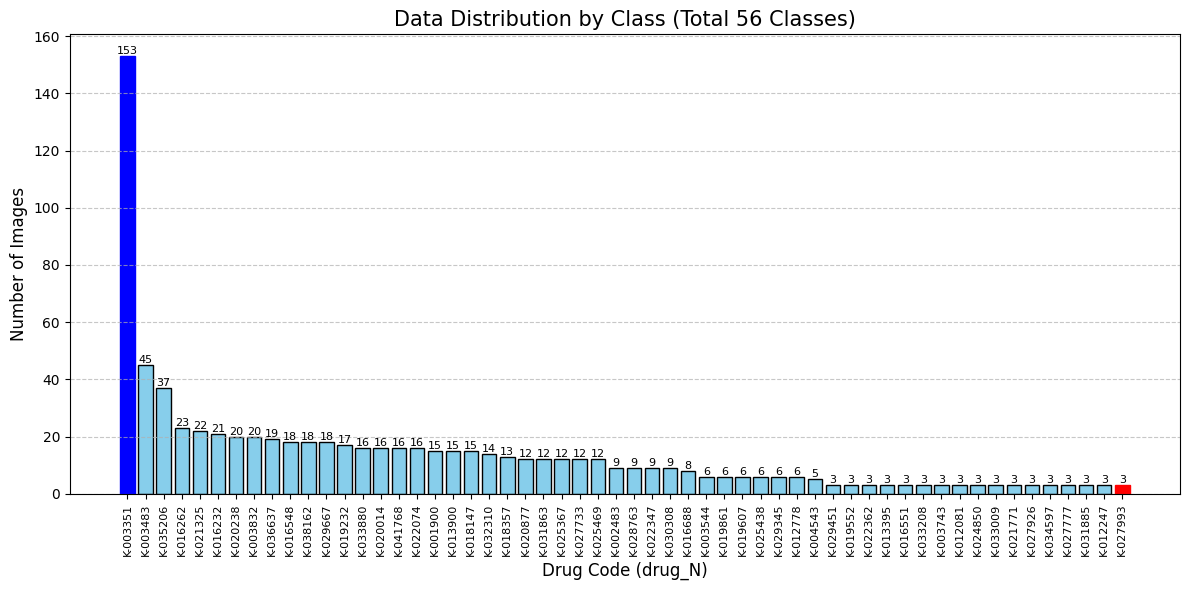

Data Balance Report
Most Frequent: K-003351 (153 images)
Least Frequent: K-027993 (3 images)
Average Images per Class: 13.6
----------------------------------------
Critical Warning: 29 classes have less than 10 images!
Need Augmentation for: ['K-002483', 'K-028763', 'K-022347', 'K-030308', 'K-016688', 'K-003544', 'K-019861', 'K-019607', 'K-025438', 'K-029345', 'K-012778', 'K-004543', 'K-029451', 'K-019552', 'K-022362', 'K-013395', 'K-016551', 'K-033208', 'K-003743', 'K-012081', 'K-024850', 'K-033009', 'K-021771', 'K-027926', 'K-034597', 'K-027777', 'K-031885', 'K-012247', 'K-027993']


In [4]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

# 1. Configuration (Use your local path)
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 

# Get File List
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)
print(f"Total Files: {len(json_files)}")

# 2. Data Extraction
class_counts = {}

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # Get Class Name (drug_N)
        # 데이터 위치가 조금씩 다를 수 있어 안전하게 가져옵니다.
        drug_n = data.get('drug_N')
        if not drug_n and 'images' in data and len(data['images']) > 0:
            drug_n = data['images'][0].get('drug_N')
            
        if drug_n:
            if drug_n in class_counts:
                class_counts[drug_n] += 1
            else:
                class_counts[drug_n] = 1

    except Exception as e:
        print(f"Error: {e}")

# Convert to Series for easy plotting
s = pd.Series(class_counts).sort_values(ascending=False) # 많은 순서대로 정렬

# 3. Visualization
plt.figure(figsize=(12, 6))

# Bar Chart
bars = plt.bar(s.index, s.values, color='skyblue', edgecolor='black')

# Highlight Min/Max
bars[0].set_color('blue')   # Max
bars[-1].set_color('red')   # Min

# Labels & Title
plt.title(f'Data Distribution by Class (Total {len(s)} Classes)', fontsize=15)
plt.xlabel('Drug Code (drug_N)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=90, fontsize=8) # 글자가 겹치지 않게 회전
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height, '%d' % int(height), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 4. Text Report
print("="*40)
print("Data Balance Report")
print("="*40)
print(f"Most Frequent: {s.index[0]} ({s.values[0]} images)")
print(f"Least Frequent: {s.index[-1]} ({s.values[-1]} images)")
print(f"Average Images per Class: {s.mean():.1f}")
print("-" * 40)
# 데이터가 10개 미만인 희귀 클래스 찾기
rare_classes = s[s < 10]
print(f"Critical Warning: {len(rare_classes)} classes have less than 10 images!")
if len(rare_classes) > 0:
    print("Need Augmentation for:", list(rare_classes.index))

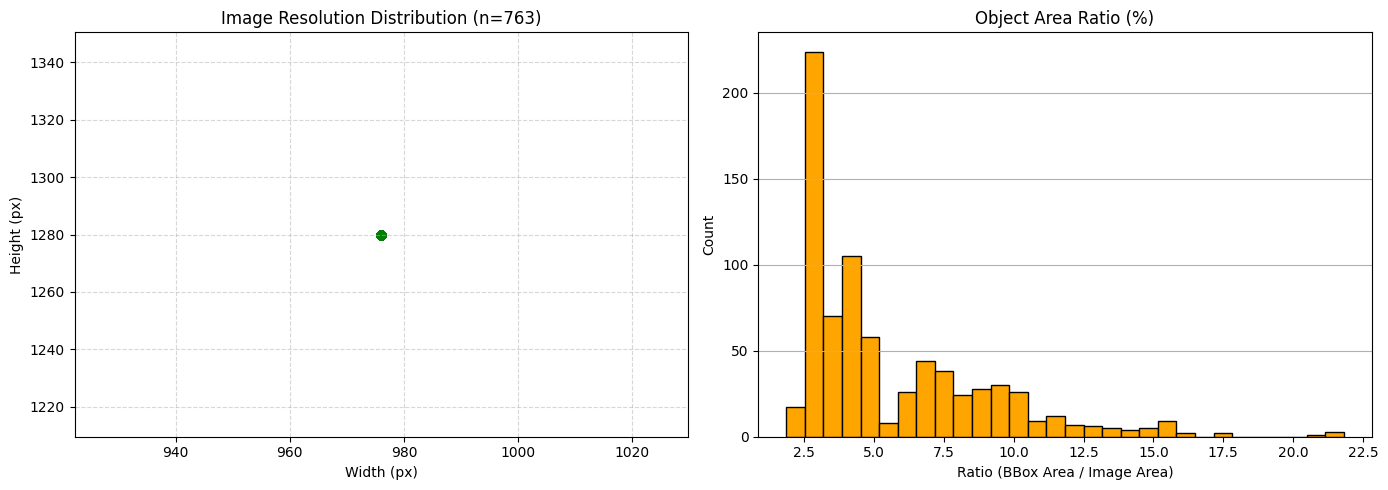

📏 이미지 및 객체 크기 분석 결과
1. 이미지 해상도 종류: 1가지
   - 최소 크기: 976 x 1280
   - 최대 크기: 976 x 1280
   - 가장 많은 크기: (np.int64(976), np.int64(1280)) (대표 해상도)
--------------------------------------------------
2. 알약 크기 비율 (평균): 전체 이미지의 5.63%
   - 가장 작은 알약: 1.86% (학습 난이도 높음)
   - 가장 큰 알약: 21.81%


In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

# 1. 경로 설정 (아까 성공했던 경로)
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

stats = []

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # 이미지 정보 (W, H)
        img_w, img_h = 0, 0
        if 'images' in data and len(data['images']) > 0:
            img_w = data['images'][0].get('width')
            img_h = data['images'][0].get('height')
            
        # 박스 정보 (B-Box Area)
        bbox_area = 0
        if 'annotations' in data:
            for ann in data['annotations']:
                # bbox format usually [x, y, w, h]
                w = ann['bbox'][2]
                h = ann['bbox'][3]
                bbox_area += (w * h) # 여러 개일 경우 합산
        
        # 비율 계산 (이미지 대비 객체 크기 %)
        ratio = 0
        if img_w > 0 and img_h > 0:
            ratio = (bbox_area / (img_w * img_h)) * 100
            
        stats.append({
            'width': img_w,
            'height': img_h,
            'ratio': ratio
        })

    except Exception:
        pass

df = pd.DataFrame(stats)

# --- 결과 시각화 ---
plt.figure(figsize=(14, 5))

# 1. 이미지 크기 분포 (산점도)
plt.subplot(1, 2, 1)
plt.scatter(df['width'], df['height'], alpha=0.5, color='green')
plt.title(f'Image Resolution Distribution (n={len(df)})')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. 객체 크기 비율 (히스토그램)
plt.subplot(1, 2, 2)
plt.hist(df['ratio'], bins=30, color='orange', edgecolor='black')
plt.title('Object Area Ratio (%)')
plt.xlabel('Ratio (BBox Area / Image Area)')
plt.ylabel('Count')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# --- 텍스트 요약 ---
print("="*50)
print("📏 이미지 및 객체 크기 분석 결과")
print("="*50)
print(f"1. 이미지 해상도 종류: {len(df.groupby(['width', 'height']))}가지")
print(f"   - 최소 크기: {df['width'].min()} x {df['height'].min()}")
print(f"   - 최대 크기: {df['width'].max()} x {df['height'].max()}")
print(f"   - 가장 많은 크기: {df.groupby(['width', 'height']).size().idxmax()} (대표 해상도)")
print("-" * 50)
print(f"2. 알약 크기 비율 (평균): 전체 이미지의 {df['ratio'].mean():.2f}%")
print(f"   - 가장 작은 알약: {df['ratio'].min():.2f}% (학습 난이도 높음)")
print(f"   - 가장 큰 알약: {df['ratio'].max():.2f}%")
print("="*50)

[이미지 규격 분석]

해상도 통일성: 전체 데이터셋이 976x1280 (Portrait) 단일 해상도로 구성되어 있어, 별도의 해상도 정규화 과정이 불필요함.

객체 점유율: 평균 5.63%이나, 최소 1.86%의 소형 객체가 존재함.

전처리 전략: 정보 손실 방지를 위해 모델 입력 해상도를 640px 이상으로 유지하고, 학습 시 Mosaic Augmentation 등을 통해 소형 객체 탐지력을 보완할 예정.

In [6]:
import os
import json
from glob import glob

# 1. 경로 설정
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

missing_files = []

print(f"결측치 검사 시작: 총 {len(json_files)}개 파일 스캔 중...")

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # 데이터 추출 시도
        drug_n = None
        mapping_code = None
        
        if 'images' in data and len(data['images']) > 0:
            drug_n = data['images'][0].get('drug_N')
            mapping_code = data['images'][0].get('dl_mapping_code')
        
        # 🚨 검증: 둘 중 하나라도 없거나(None), 빈 문자열("")인 경우
        if not drug_n or not mapping_code:
            missing_files.append({
                'file': os.path.basename(file_path),
                'drug_N': drug_n,
                'dl_mapping_code': mapping_code
            })

    except Exception as e:
        print(f"파일 읽기 에러: {file_path}")

# 결과 리포트
print("=" * 50)
if len(missing_files) == 0:
    print("✅ 결측치 없음! (Clean Data)")
    print("모든 파일에 drug_N과 dl_mapping_code가 꽉 차 있습니다.")
else:
    print(f"⚠️ 결측치 발견! (총 {len(missing_files)}건)")
    print("아래 파일들은 코드가 비어 있습니다:")
    print("-" * 30)
    for item in missing_files:
        print(f"파일: {item['file']}")
        print(f"   -> drug_N: {item['drug_N']}")
        print(f"   -> mapping: {item['dl_mapping_code']}")

결측치 검사 시작: 총 763개 파일 스캔 중...
✅ 결측치 없음! (Clean Data)
모든 파일에 drug_N과 dl_mapping_code가 꽉 차 있습니다.


In [7]:
import os
import json
from glob import glob

# 1. 경로 설정 (아까 그 경로 그대로)
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

mismatch_list = []
total_checked = 0

print(f"검사 시작: 총 {len(json_files)}개 파일 확인 중...")

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # JSON 구조에 따라 위치가 다를 수 있어 확인
        # 보통 images 리스트 안의 첫 번째 객체에 정보가 있습니다.
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            
            # 두 값 가져오기 (없으면 None)
            drug_n = img_info.get('drug_N')
            mapping_code = img_info.get('dl_mapping_code')
            
            # 둘 다 데이터가 있을 때만 비교
            if drug_n is not None and mapping_code is not None:
                total_checked += 1
                if drug_n != mapping_code:
                    mismatch_list.append({
                        'file': os.path.basename(file_path),
                        'drug_N': drug_n,
                        'dl_mapping_code': mapping_code
                    })

    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# 결과 출력
print("=" * 50)
print(f"검증 결과 (총 {total_checked}건 비교)")
print("=" * 50)

if len(mismatch_list) == 0:
    print("✅ 완벽 일치! (100% Matched)")
    print("결론: 두 컬럼은 현재 완전히 동일한 값을 가집니다.")
    print("-> 둘 중 편한 걸 변수로 쓰시면 됩니다.")
else:
    print(f"🚨 불일치 발견! (총 {len(mismatch_list)}건)")
    print("-> 데이터 라벨링에 오류가 있거나, 의도적으로 다르게 매핑된 데이터입니다.")
    print("-" * 30)
    for item in mismatch_list[:5]: # 5개만 예시로 출력
        print(f"파일: {item['file']} | drug_N: {item['drug_N']} != map: {item['dl_mapping_code']}")

검사 시작: 총 763개 파일 확인 중...
검증 결과 (총 763건 비교)
✅ 완벽 일치! (100% Matched)
결론: 두 컬럼은 현재 완전히 동일한 값을 가집니다.
-> 둘 중 편한 걸 변수로 쓰시면 됩니다.


EDA, 데이터 분석, 엑셀 정리할 때: drug_N을 쓰세요. (이건 약의 신상정보니까요.)

내일 모델 학습용 라벨(YOLO 등) 만들 때: dl_mapping_code를 변수명으로 쓰세요. ("이건 모델 학습용이야"라고 코드에 명시하는 효과가 있습니다.)

In [8]:
import os
import json
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split

# 1. 설정 (경로 유지)
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

# 2. 데이터 목록 만들기
data_list = []
print(f"데이터 로딩 중... (총 {len(json_files)}개)")

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if 'images' in data and len(data['images']) > 0:
            drug_n = data['images'][0].get('drug_N')
            if drug_n:
                data_list.append({
                    'filename': os.path.basename(file_path),
                    'full_path': file_path,
                    'label': drug_n
                })
    except Exception:
        pass

df = pd.DataFrame(data_list)

# 3. 층화 추출 (Stratified Split)
try:
    train_df, val_df = train_test_split(
        df, 
        test_size=0.2,          
        stratify=df['label'],   
        random_state=42         
    )

    train_df['split'] = 'train'
    val_df['split'] = 'val'
    final_df = pd.concat([train_df, val_df])

    # ==========================================
    # ⭐ 핵심: 바탕화면 경로 찾아서 저장하기
    # ==========================================
    desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
    save_path = os.path.join(desktop_path, 'dataset_split.csv')

    # 저장 (인덱스 빼고 깔끔하게)
    final_df[['filename', 'label', 'split']].to_csv(save_path, index=False)

    print("="*50)
    print(f"✅ 바탕화면에 저장 완료!")
    print(f"📂 경로: {save_path}")
    print("="*50)

    # 4. 결과 요약 출력
    rare_class = df['label'].value_counts().idxmin()
    print(f"🔍 희귀 클래스 '{rare_class}' 분배 확인:")
    print(f" - 학습용: {len(train_df[train_df['label'] == rare_class])}개")
    print(f" - 검증용: {len(val_df[val_df['label'] == rare_class])}개")

except ValueError as e:
    print(f"🚨 에러 발생: {e}")
    print("데이터 개수가 너무 적은 클래스가 있어서 분할에 실패했을 수 있습니다.")

데이터 로딩 중... (총 763개)
✅ 바탕화면에 저장 완료!
📂 경로: C:\Users\qwer0\Desktop\dataset_split.csv
🔍 희귀 클래스 'K-029451' 분배 확인:
 - 학습용: 2개
 - 검증용: 1개


In [9]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 윈도우(Windows) 사용자라면 이 코드를 꼭 실행하세요!
font_path = "C:/Windows/Fonts/malgun.ttf"
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)

In [10]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob

# 한글 폰트 설정 (깨짐 방지용)
# 윈도우 사용자라면 아래 코드가 필수입니다.
from matplotlib import font_manager, rc
font_path = "C:/Windows/Fonts/malgun.ttf"
if os.path.exists(font_path):
    font = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font)
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로딩 (경로 설정)
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

data_list = []
print(f"데이터 로딩 중... (총 {len(json_files)}개)")

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            
            # 데이터 추출
            print_exist = 1 if (img_info.get('print_front') or img_info.get('print_back')) else 0
            
            data_list.append({
                'Shape': img_info.get('chart', 'Unknown'),          
                'Has_Text': 'Yes' if print_exist else 'No',
                'Color': img_info.get('color_class1', 'Unknown'),
                'Long_Axis': float(img_info.get('leng_long', 0) or 0),   
                'Short_Axis': float(img_info.get('leng_short', 0) or 0)
            })
    except Exception:
        pass

df = pd.DataFrame(data_list)

데이터 로딩 중... (총 763개)


C:\Users\qwer0\AppData\Local\Temp\ipykernel_16320\2233915739.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shape_counts.values, y=shape_counts.index, palette='viridis')


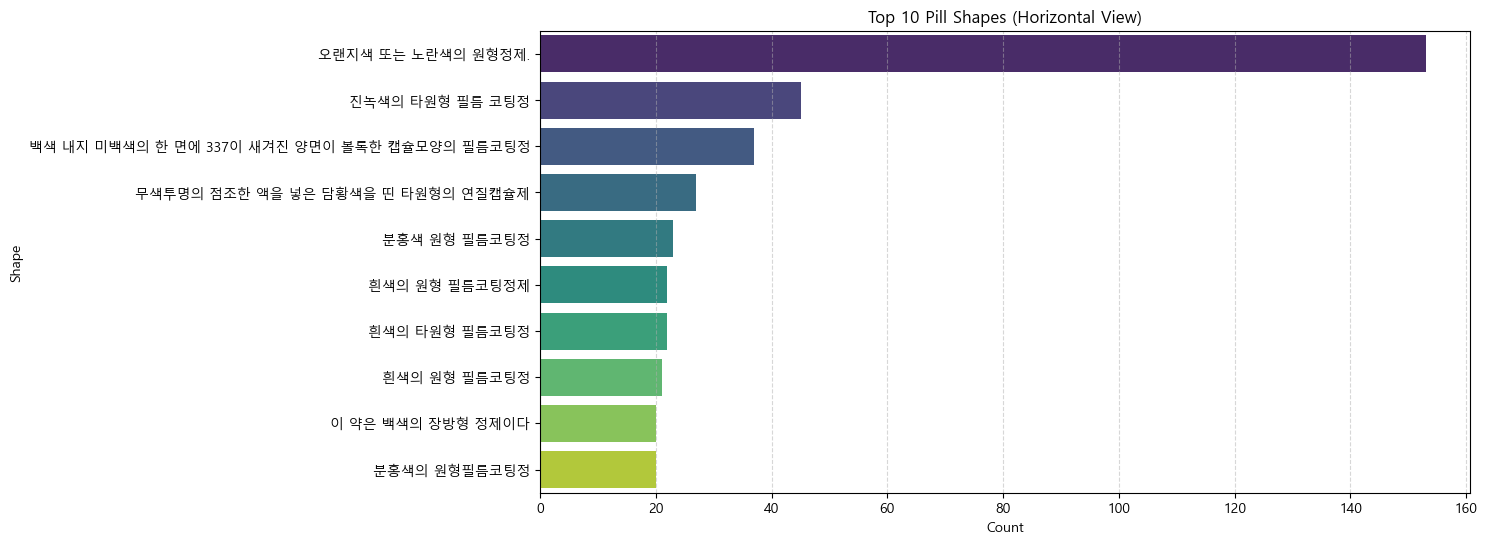

In [11]:
# ========================================================
# 🎨 1번 그래프: 알약 모양 (가로 막대 그래프) - 글자 안 깨짐!
# ========================================================
plt.figure(figsize=(12, 6)) # 가로로 넓게
shape_counts = df['Shape'].value_counts().head(10) # 상위 10개만
# x와 y를 바꿔서 가로로 눕힘 (orient='h')
sns.barplot(x=shape_counts.values, y=shape_counts.index, palette='viridis')
plt.title('Top 10 Pill Shapes (Horizontal View)')
plt.xlabel('Count')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

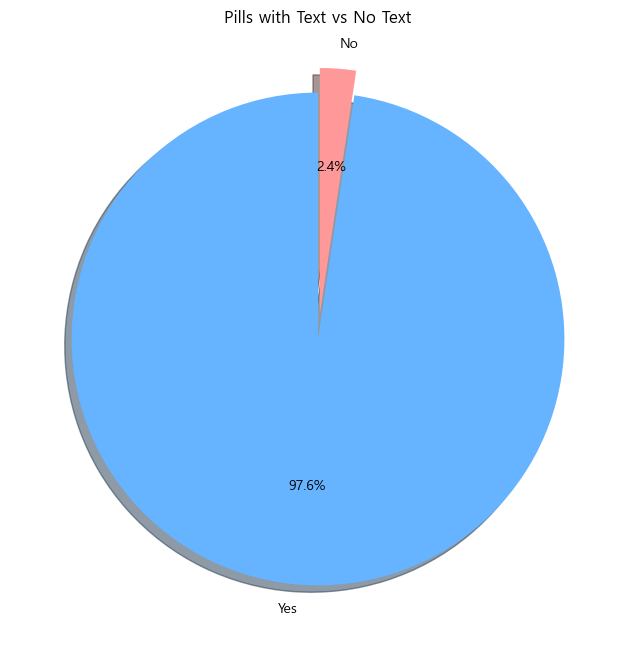

In [12]:
# ========================================================
# 🎨 2번 그래프: 식별 문자 유무 (파이 차트)
# ========================================================
plt.figure(figsize=(8, 8))
text_counts = df['Has_Text'].value_counts()
# explode: 작은 조각(No)을 피자처럼 떼어내서 강조함
explode = [0.1 if idx == 'No' else 0 for idx in text_counts.index]
plt.pie(text_counts, labels=text_counts.index, autopct='%1.1f%%', 
        colors=['#66b3ff','#ff9999'], startangle=90, explode=explode, shadow=True)
plt.title('Pills with Text vs No Text')
plt.show()

C:\Users\qwer0\AppData\Local\Temp\ipykernel_16320\2101970385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.values, y=color_counts.index, palette='rocket')


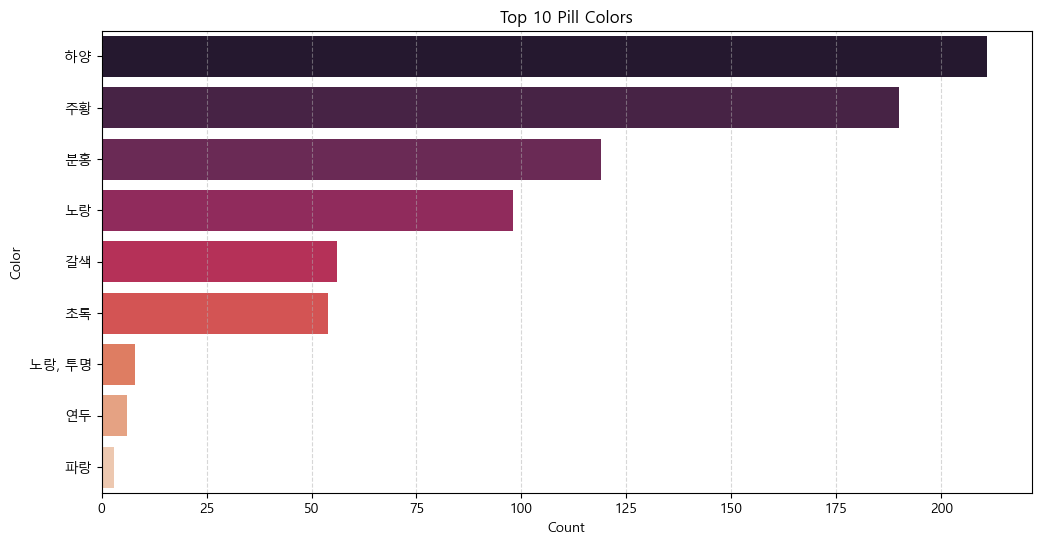

In [13]:
# ========================================================
# 🎨 3번 그래프: 알약 색상 (가로 막대 그래프)
# ========================================================
plt.figure(figsize=(12, 6))
color_counts = df['Color'].value_counts().head(10)
sns.barplot(x=color_counts.values, y=color_counts.index, palette='rocket')
plt.title('Top 10 Pill Colors')
plt.xlabel('Count')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

데이터 로딩 및 그래프 준비 중... (총 763개)


C:\Users\qwer0\AppData\Local\Temp\ipykernel_16320\3987342095.py:57: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



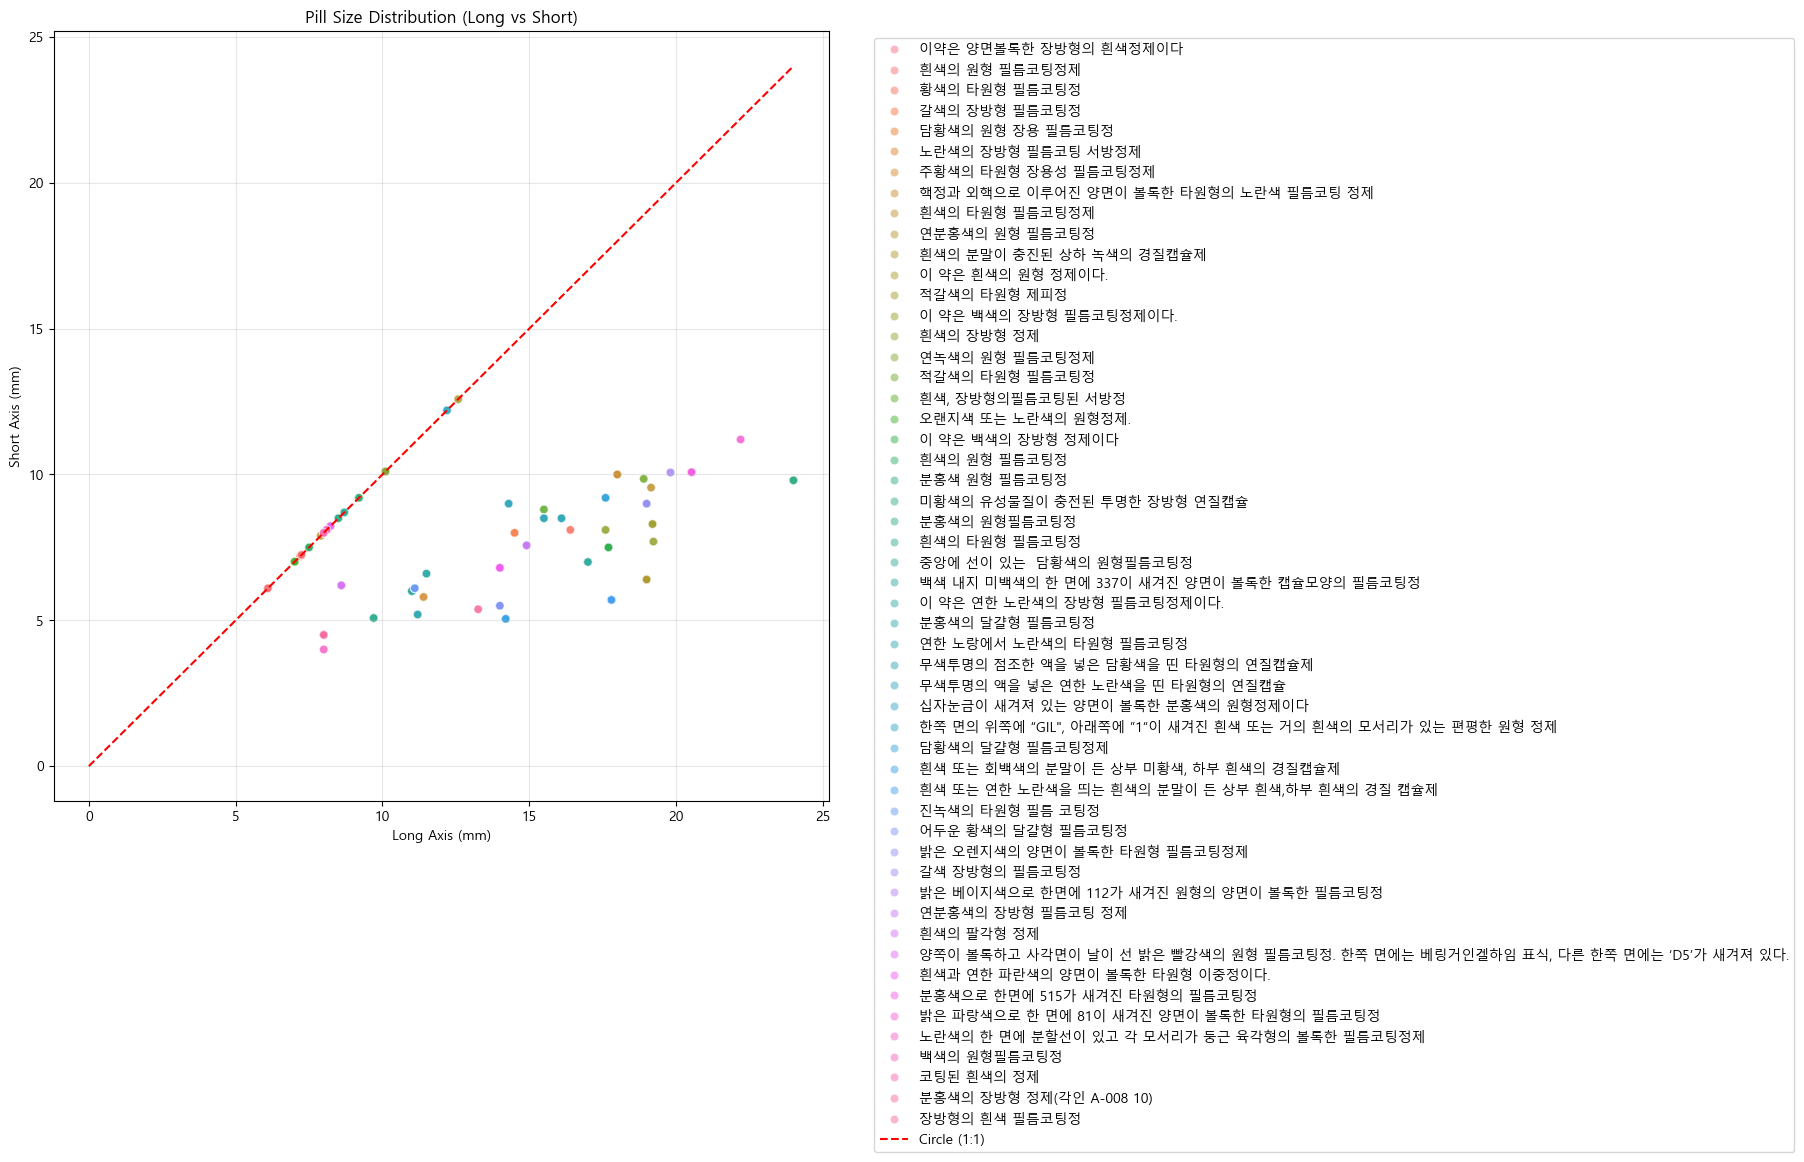

In [16]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import font_manager, rc

# 1. 폰트 설정 (한글 깨짐 방지 - 윈도우용)
font_path = "C:/Windows/Fonts/malgun.ttf"
if os.path.exists(font_path):
    font = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font)
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로딩
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

data_list = []
print(f"데이터 로딩 및 그래프 준비 중... (총 {len(json_files)}개)")

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            
            # 사용자님 코드가 사용하는 컬럼명에 맞춰서 데이터 추출
            data_list.append({
                'Shape': img_info.get('chart', 'Unknown'),          
                'Long_Axis': float(img_info.get('leng_long', 0) or 0),   
                'Short_Axis': float(img_info.get('leng_short', 0) or 0)
            })
    except Exception:
        pass

df = pd.DataFrame(data_list)

# ========================================================
# 🎨 4번 그래프: 크기 분포 (산점도) - 사용자 요청 코드
# ========================================================
plt.figure(figsize=(10, 10)) # 정사각형
sns.scatterplot(x='Long_Axis', y='Short_Axis', data=df, alpha=0.5, hue='Shape', legend=True) 
# Tip: legend=False를 True로 바꿨습니다. 그래야 무슨 모양인지 색깔표가 나옵니다!

max_val = max(df['Long_Axis'].max(), df['Short_Axis'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Circle (1:1)') # 기준선

plt.title('Pill Size Distribution (Long vs Short)')
plt.xlabel('Long Axis (mm)')
plt.ylabel('Short Axis (mm)')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례가 그래프 가리지 않게 밖으로 뺌
plt.tight_layout()
plt.show()

In [18]:
import os
import json
import pandas as pd
from glob import glob

# 1. 데이터 경로 설정
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

data_list = []
print(f"데이터 정밀 검사 중... (총 {len(json_files)}개)")

# 2. 모든 파일 열어서 값 확인
for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            
            # 사용자님이 요청하신 키값 확인
            # (값이 없거나 None이면 빈 문자열 '' 로 처리)
            kr_name = img_info.get('di_company_mf')
            en_name = img_info.get('di_company_mf_en')
            
            # 데이터 수집
            data_list.append({
                'filename': os.path.basename(file_path),
                'di_company_mf (한글)': kr_name if kr_name else None,    # 없으면 None
                'di_company_mf_en (영문)': en_name if en_name else None
            })
    except Exception:
        pass

df = pd.DataFrame(data_list)

# 3. 결과 분석 및 출력
total = len(df)
kr_filled = df['di_company_mf (한글)'].count() # None이 아닌 것 개수
en_filled = df['di_company_mf_en (영문)'].count()

print("\n" + "="*50)
print("🧐 위탁 제조사 필드 데이터 존재 여부 확인")
print("="*50)

# 한글 필드 확인
if kr_filled == 0:
    print(f"❌ 'di_company_mf' (한글) : 모든 데이터가 비어있습니다! (0/{total})")
else:
    print(f"✅ 'di_company_mf' (한글) : {kr_filled}개 데이터가 있습니다. ({kr_filled/total*100:.1f}%)")
    print(f"   ㄴ 예시: {df['di_company_mf (한글)'].dropna().unique()[:3]}")

print("-" * 30)

# 영문 필드 확인
if en_filled == 0:
    print(f"❌ 'di_company_mf_en' (영문) : 모든 데이터가 비어있습니다! (0/{total})")
else:
    print(f"✅ 'di_company_mf_en' (영문) : {en_filled}개 데이터가 있습니다. ({en_filled/total*100:.1f}%)")
    print(f"   ㄴ 예시: {df['di_company_mf_en (영문)'].dropna().unique()[:3]}")

print("="*50)

# 4. 만약 둘 다 비어있다면? -> 다른 키일 가능성 제시
if kr_filled == 0 and en_filled == 0:
    print("\n💡 팁: 이 필드들이 다 비어있다면, 'trust_entp_name' 키를 대신 사용했는지 확인해보세요.")

데이터 정밀 검사 중... (총 763개)

🧐 위탁 제조사 필드 데이터 존재 여부 확인
✅ 'di_company_mf' (한글) : 126개 데이터가 있습니다. (16.5%)
   ㄴ 예시: <StringArray>
['일양바이오팜(주)', '고려제약(주)', '코오롱제약(주)']
Length: 3, dtype: str
------------------------------
✅ 'di_company_mf_en' (영문) : 39개 데이터가 있습니다. (5.1%)
   ㄴ 예시: <StringArray>
['Ilyang Bio Pharm', 'Korean Drug', 'Kolon Pharm']
Length: 3, dtype: str


In [19]:
import os
import json
import pandas as pd
from glob import glob

# 1. 데이터 로딩
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

data_list = []
print(f"데이터 분석 중... (총 {len(json_files)}개)")

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            
            # 위탁 제조사(한글) 정보가 있는 경우만 수집
            trust_factory = img_info.get('di_company_mf')
            if trust_factory: # 값이 있는 경우만!
                data_list.append({
                    'Factory': trust_factory,           # 실제 만든 공장 (위탁사)
                    'Brand': img_info.get('entp_name'), # 판매하는 회사 (브랜드)
                    'Drug_Name': img_info.get('dl_name'), # 약 이름
                    'Shape': img_info.get('chart'),       # 모양
                    'Color': img_info.get('color_class1') # 색상
                })
    except Exception:
        pass

df = pd.DataFrame(data_list)

# 2. 분석 결과 출력
if not df.empty:
    print("\n" + "="*50)
    print("🏭 위탁 생산(126개) 심층 분석 보고서")
    print("="*50)

    # (1) 가장 많은 약을 대신 만들어준 공장 Top 5
    factory_counts = df['Factory'].value_counts()
    print(f"\n1. 가장 바쁜 위탁 공장 Top 5 (총 {len(factory_counts)}개 공장):")
    print(factory_counts.head(5))

    # (2) '쌍둥이 약' 의심 사례 찾기
    # 같은 공장(Factory)에서 만들었는데, 판매사(Brand)나 약 이름이 다른 경우
    print(f"\n2. [주의] 한 공장에서 여러 회사의 약을 만든 사례:")
    
    # 공장별로 그룹화
    grouped = df.groupby('Factory')
    
    found_case = False
    for factory, group in grouped:
        # 한 공장에서 만든 약의 종류가 2개 이상인 경우만 출력
        if len(group) >= 2:
            found_case = True
            print(f"\n🏭 공장: {factory} (총 {len(group)}개 품목 생산)")
            # 보기 좋게 출력 (약 이름, 모양, 색상)
            display_cols = group[['Drug_Name', 'Brand', 'Shape', 'Color']]
            print(display_cols.to_string(index=False))
            print("-" * 40)
            
    if not found_case:
        print("-> 다행히 한 공장에서 여러 약이 섞인 케이스는 발견되지 않았습니다.")

else:
    print("위탁 제조사 정보가 있는 데이터가 없습니다.")

데이터 분석 중... (총 763개)

🏭 위탁 생산(126개) 심층 분석 보고서

1. 가장 바쁜 위탁 공장 Top 5 (총 13개 공장):
Factory
Sanofi Winthrop Industrie                                        20
Delpharm Milano S.r.l                                            16
Pfizer Manufacturing Deutschland GmbH Betriebsstatte Freiburg    15
(주)서흥, (주)알피바이오, 코스맥스파마(주)                                       14
(주)서흥                                                            13
Name: count, dtype: int64

2. [주의] 한 공장에서 여러 회사의 약을 만든 사례:

🏭 공장: (주)서흥 (총 13개 품목 생산)
              Drug_Name Brand                             Shape Color
종근당글리아티린연질캡슐(콜린알포세레이트)   None 무색투명의 점조한 액을 넣은 담황색을 띤 타원형의 연질캡슐제    갈색
종근당글리아티린연질캡슐(콜린알포세레이트)   None 무색투명의 점조한 액을 넣은 담황색을 띤 타원형의 연질캡슐제    갈색
종근당글리아티린연질캡슐(콜린알포세레이트)   None 무색투명의 점조한 액을 넣은 담황색을 띤 타원형의 연질캡슐제    갈색
종근당글리아티린연질캡슐(콜린알포세레이트)   None 무색투명의 점조한 액을 넣은 담황색을 띤 타원형의 연질캡슐제    갈색
종근당글리아티린연질캡슐(콜린알포세레이트)   None 무색투명의 점조한 액을 넣은 담황색을 띤 타원형의 연질캡슐제    갈색
종근당글리아티린연질캡슐(콜린알포세레이트)   None 무색투명의 점조한 액을 넣은 담황색을 띤 타원형의 연질캡슐제   

1.공장 하나당 약은 한 종류뿐
리스트를 자세히 보면, 각 공장 밑에 써있는 약 이름(Drug_Name)이 전부 똑같음

Sanofi: 플라빅스정만 20개 (사진이 20장이라는 뜻)

Delpharm: 마도파정만 16개

Pfizer: 리리카캡슐만 15개

한 공장에서 모양이 똑같은 A약, B약, C약을 마구 찍어내는 상황은 이 데이터셋에 없음. AI가 공장 때문에 헷갈려 할 일은 거의 없음.

2. 서흥 (이건 주의!)
하지만 매의 눈으로 봐야 할 부분이 딱 하나 있음. 바로 (주)서흥임.

그룹 1: (주)서흥 공장 -> 종근당글리아티린연질캡슐 생산

그룹 2: (주)서흥, (주)알피바이오... 공장 -> 글리아타민연질캡슐 생산

이 두 약은 이름이 다름. (종근당 vs 글리아타민) 하지만 모양(타원형 연질캡슐)과 색깔(갈색/담황색)이 놀라울 정도로 똑같음. 실제로 두 약은 성분(콜린알포세레이트)도 같고, 제조 기술도 공유하는 라이벌 관계의 약임.

-> 전략: 나중에 학습이 끝나면, AI가 "종근당글리아티린"과 "글리아타민"을 서로 구분할 수 있는지 꼭 확인해봐야 함. (아마 제일 많이 틀리는 오답 노트가 될 것 같음.)

In [24]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import font_manager, rc

# 1. 한글 폰트 설정 (윈도우 기준)
font_path = "C:/Windows/Fonts/malgun.ttf"
if os.path.exists(font_path):
    font = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font)
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로딩
base_path = r'C:\Users\qwer0\Downloads\ai-07-object-detection\sprint_ai_project1_data' 
json_files = glob(os.path.join(base_path, '**', '*.json'), recursive=True)

data_list = []
print(f"데이터 분석 중... (총 {len(json_files)}개)")

for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        if 'images' in data and len(data['images']) > 0:
            img_info = data['images'][0]
            
            # ⭐ 핵심 수정: 알려주신 'dl_company' 사용!
            manufacturer = img_info.get('dl_company')
            if not manufacturer: # 한글 없으면 영문이라도
                manufacturer = img_info.get('dl_company_en', 'Unknown')
                
            data_list.append({
                'label': img_info.get('drug_N'),
                'drug_name': img_info.get('dl_name'),       # 약 이름
                'manufacturer': manufacturer,               # 제조사 (수정됨)
                'shape': img_info.get('chart', 'Unknown'),  # 모양
                'color': img_info.get('color_class1', 'Unknown') # 색상
            })
    except Exception:
        pass

df = pd.DataFrame(data_list)

# --- 분석 결과 출력 ---

# 1. 제조사(업체명) Top 10 확인
if not df.empty:
    top_manufacturers = df['manufacturer'].value_counts().head(10)
    
    print("\n" + "="*50)
    print("🏭 제조사(dl_company) 점유율 Top 10")
    print("="*50)
    print(top_manufacturers)
    print("-" * 50)

    # 2. '쌍둥이 알약' 의심군 찾기 (같은 제조사 + 같은 모양 + 같은 색상)
    # 제조사는 같은데 약 이름(Label)이 다른 경우를 그룹화
    grouped = df.groupby(['manufacturer', 'shape', 'color'])['label'].unique()

    print("\n🚨 [심층 분석] 같은 제조사 내 '쌍둥이 알약' (모양/색상 동일)")
    print("="*50)
    count = 0
    for idx, labels in grouped.items():
        # 같은 그룹(제조사+모양+색) 안에 서로 다른 약 코드가 2개 이상 섞여 있다면?
        if len(labels) > 1:
            count += 1
            company, shape, color = idx
            print(f"🏭 제조사: {company}")
            print(f"   ㄴ 특징: {shape} / {color}")
            print(f"   ㄴ 섞여있는 약 코드들: {labels}")
            
            # 어떤 약 이름들이 섞였는지 구체적으로 확인
            names = df[df['label'].isin(labels)]['drug_name'].unique()
            print(f"   ㄴ 약 이름 목록: {names}")
            print("-" * 30)
            
            if count >= 5: # 너무 많으면 5개만 보고 중단
                print("... (이하 생략) ...")
                break

    if count == 0:
        print("✅ 다행히 동일 제조사 내에서 외형(모양+색상)이 겹치는 다른 약은 없습니다.")
    else:
        print(f"⚠️ 총 {count}개 그룹에서 시각적 혼동 가능성이 발견됨!")

else:
    print("데이터를 불러오지 못했습니다.")

데이터 분석 중... (총 763개)

🏭 제조사(dl_company) 점유율 Top 10
manufacturer
일양약품(주)         159
한국엠에스디(주)        61
한미약품(주)          57
(주)유한양행          55
한국화이자제약(주)       45
에스케이케미칼(주)       45
한국베링거인겔하임(주)     30
한국아스트라제네카(주)     29
(주)종근당           29
한국룬드벡(주)         27
Name: count, dtype: int64
--------------------------------------------------

🚨 [심층 분석] 같은 제조사 내 '쌍둥이 알약' (모양/색상 동일)
✅ 다행히 동일 제조사 내에서 외형(모양+색상)이 겹치는 다른 약은 없습니다.


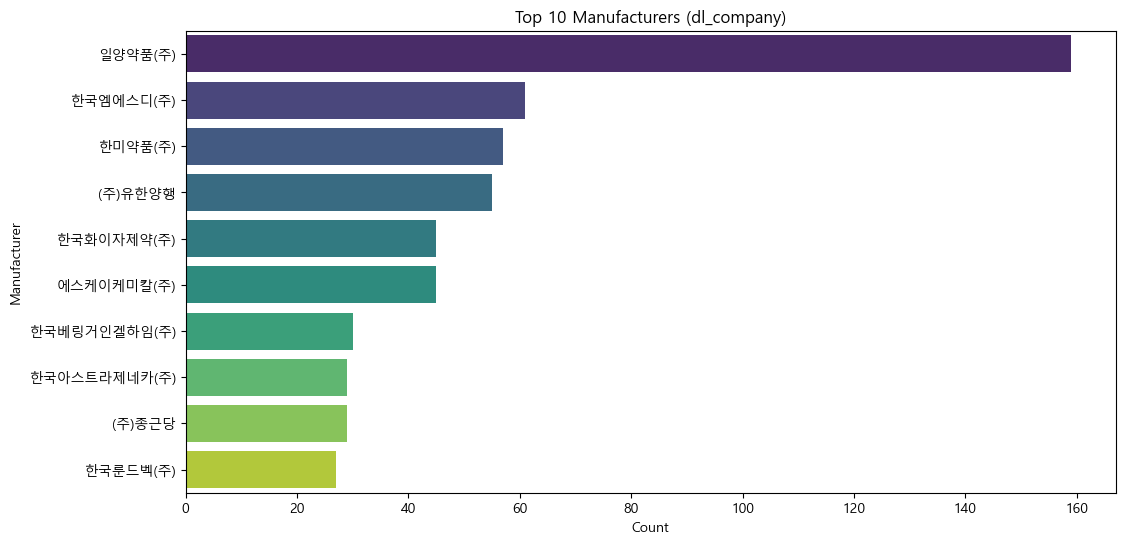

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 집계 (상위 10개 제조사 추출)
# value_counts()로 개수를 세고, reset_index()로 데이터프레임으로 변환합니다.
top10_data = df['manufacturer'].value_counts().nlargest(10).reset_index()

# 2. 컬럼 이름 재설정 (명확하게 하기 위해)
# 첫 번째 컬럼은 'manufacturer', 두 번째 컬럼(개수)은 'count'로 지정
top10_data.columns = ['manufacturer', 'count']

# --- 시각화 ---
plt.figure(figsize=(12, 6))

# 주의: 여기서 data=df 가 아니라, 위에서 만든 data=top10_data 를 써야 합니다!
sns.barplot(
    x='count', 
    y='manufacturer', 
    hue='manufacturer',  # 경고 해결을 위한 설정
    legend=False,        # 범례 숨김
    palette='viridis', 
    data=top10_data      # <--- 집계된 데이터를 넣어야 에러가 안 납니다.
)

plt.title('Top 10 Manufacturers (dl_company)')
plt.xlabel('Count')
plt.ylabel('Manufacturer')
plt.show()

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 컬럼 이름의 앞뒤 공백 제거 (가장 유력한 해결책)
df.columns = df.columns.str.strip()

# 2. 'chart' 컬럼이 존재하는지 확인 후 실행
if 'chart' in df.columns:
    print("✅ 'chart' 컬럼을 찾았습니다! 그래프를 그립니다...")

    # --- 데이터 준비 ---
    top_makers = df['manufacturer'].value_counts().nlargest(10).index
    df_top = df[df['manufacturer'].isin(top_makers)]

    # --- 그래프 그리기 ---
    fig, ax = plt.subplots(2, 1, figsize=(14, 18))

    # (1) 제조사 vs 제형 (chart)
    ct_shape = pd.crosstab(df_top['manufacturer'], df_top['chart'])
    ct_shape = ct_shape.loc[top_makers] # 순서 정렬
    sns.heatmap(ct_shape, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax[0])
    ax[0].set_title('Top 10 Manufacturers by Shape (chart)', fontsize=15)

    # (2) 제조사 vs 색상 (color_class1)
    if 'color_class1' in df.columns:
        ct_color = pd.crosstab(df_top['manufacturer'], df_top['color_class1'])
        ct_color = ct_color.loc[top_makers] # 순서 정렬
        sns.heatmap(ct_color, annot=True, fmt='d', cmap='Oranges', linewidths=0.5, ax=ax[1])
        ax[1].set_title('Top 10 Manufacturers by Color (color_class1)', fontsize=15)
    else:
        ax[1].text(0.5, 0.5, "color_class1 컬럼 없음", ha='center', fontsize=15)

    plt.tight_layout()
    plt.show()

else:
    print("❌ 오류: 여전히 'chart' 컬럼을 찾을 수 없습니다.")
    print("현재 데이터에 있는 컬럼 이름들을 확인해 보세요:")
    print(df.columns.tolist())

❌ 오류: 여전히 'chart' 컬럼을 찾을 수 없습니다.
현재 데이터에 있는 컬럼 이름들을 확인해 보세요:
['label', 'drug_name', 'manufacturer', 'shape', 'color']


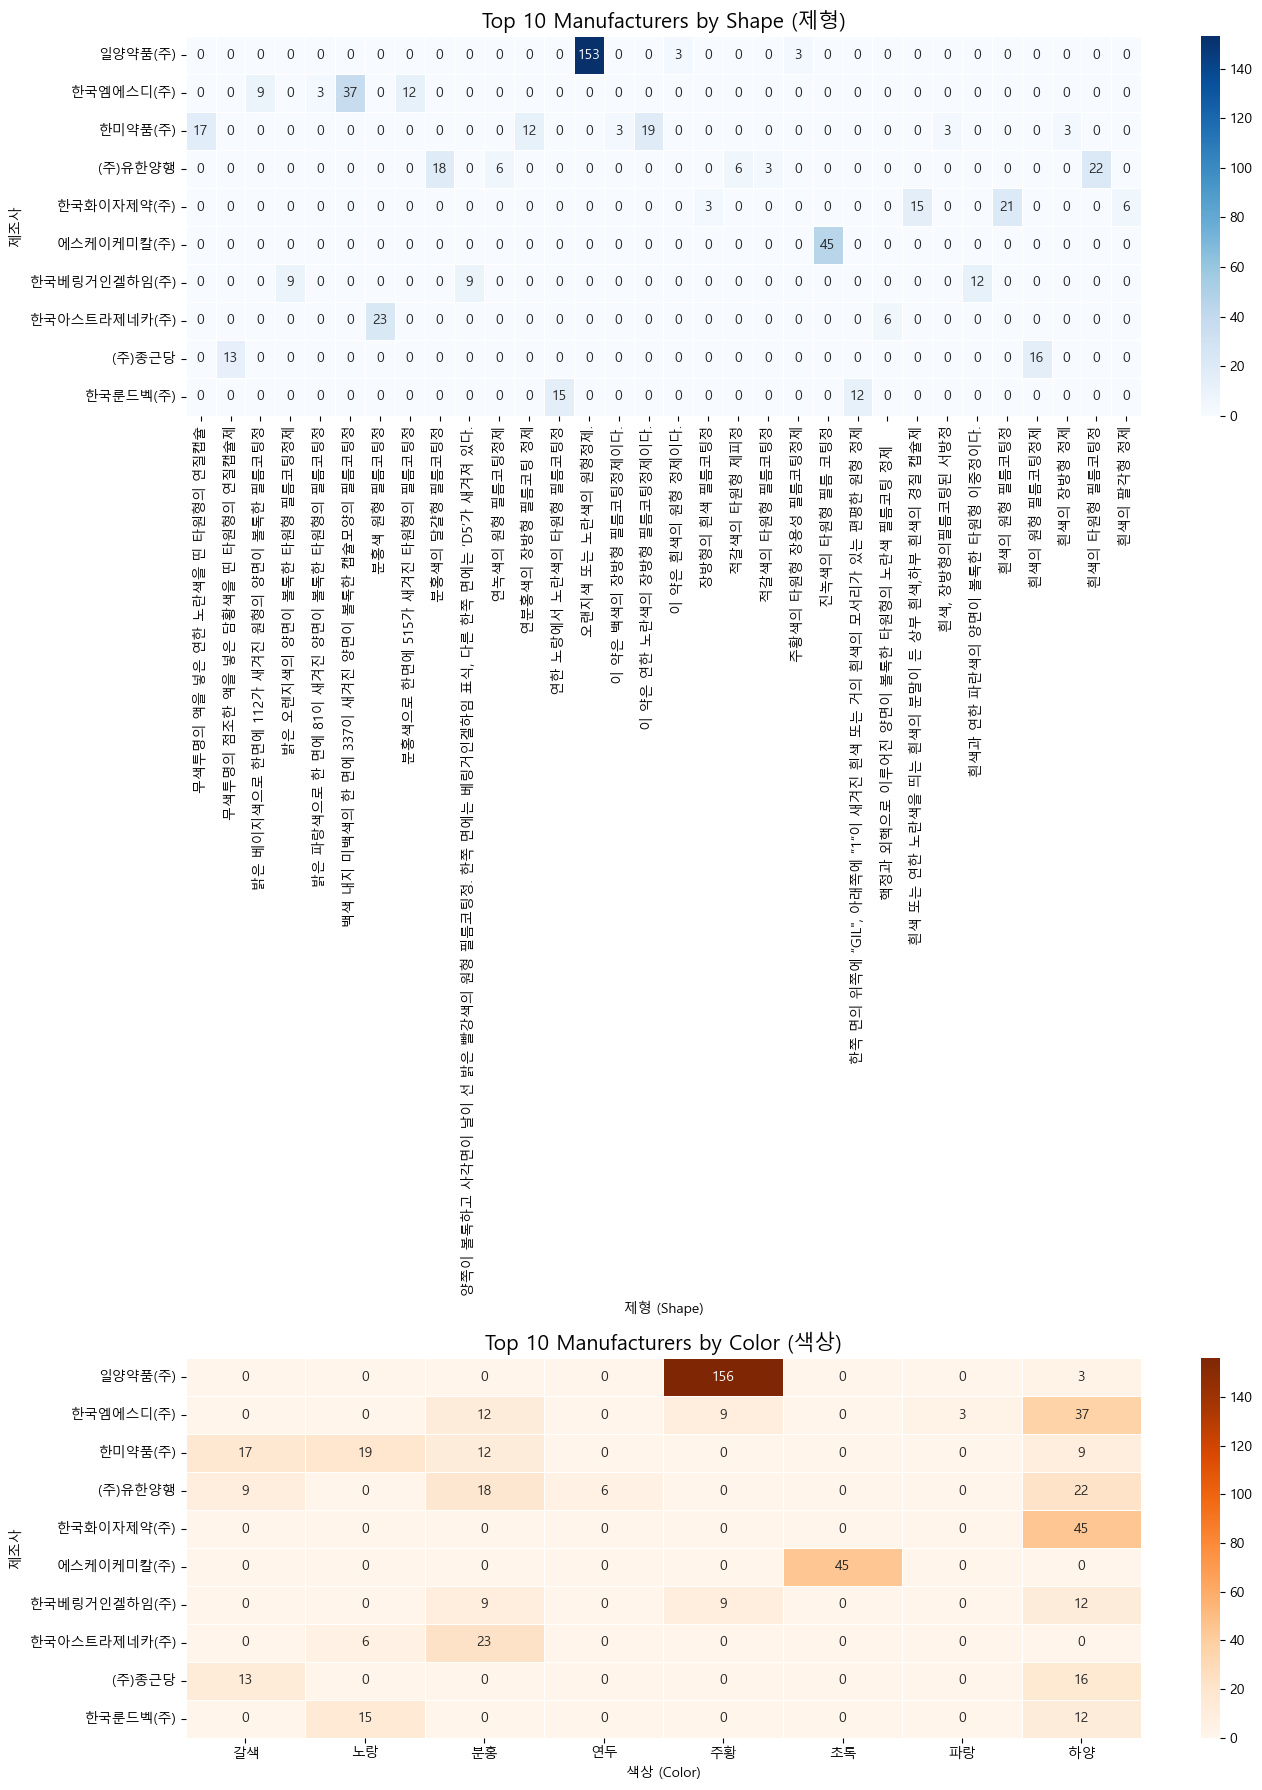

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 분석 대상: 상위 10개 제조사만 추리기
top_makers = df['manufacturer'].value_counts().nlargest(10).index
df_top = df[df['manufacturer'].isin(top_makers)]

# 2. 그래프 그리기 설 (위: 제형, 아래: 색상)
fig, ax = plt.subplots(2, 1, figsize=(14, 18)) # 그림판 크기

# --- 첫 번째 그래프: 제조사 vs 제형 (shape) ---
# 기존 'chart' 대신 'shape'를 사용합니다.
ct_shape = pd.crosstab(df_top['manufacturer'], df_top['shape'])
ct_shape = ct_shape.loc[top_makers] # 상위 제조사 순서대로 정렬

# 히트맵 그리기 (파란색 테마)
sns.heatmap(ct_shape, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax[0])
ax[0].set_title('Top 10 Manufacturers by Shape (제형)', fontsize=15)
ax[0].set_xlabel('제형 (Shape)')
ax[0].set_ylabel('제조사')

# --- 두 번째 그래프: 제조사 vs 색상 (color) ---
# 기존 'color_class1' 대신 'color'를 사용합니다.
ct_color = pd.crosstab(df_top['manufacturer'], df_top['color'])
ct_color = ct_color.loc[top_makers] # 상위 제조사 순서대로 정렬

# 히트맵 그리기 (오렌지색 테마)
sns.heatmap(ct_color, annot=True, fmt='d', cmap='Oranges', linewidths=0.5, ax=ax[1])
ax[1].set_title('Top 10 Manufacturers by Color (색상)', fontsize=15)
ax[1].set_xlabel('색상 (Color)')
ax[1].set_ylabel('제조사')

plt.tight_layout()
plt.show()

📊 시각화 분석 결과
1. 일양약품의 압도적인 '주황색' 사랑

**색상 차트(아래)**를 보면, 일양약품은 '주황' 칸에 156건이 몰려 있음.

다른 색상은 거의 없고 오직 주황색만 압도적으로 많음. 이는 수집된 일양약품 데이터가 특정 제품군(예: 비타민, 특정 브랜드 등)에 편중되어 있을 가능성을 시사함.

2. SK케미칼은 '초록색' 올인

SK케미칼은 '초록' 칸에 45건이 집중되어 있음.

**제형 차트(위)**에서도 특정 제형(45건)에 몰려 있는 것을 볼 때, 단일 품목이거나 시리즈 제품일 확률이 높음.

3. 다국적 제약사(화이자, MSD 등)는 '하양' 위주

한국화이자, 한국엠에스디, 한국아스트라제네카 등은 '하양' 색상의 비중이 가장 높고, 그 다음으로 '분홍'이나 '노랑'이 섞여 있는 일반적인 의약품 분포를 보임.